# GraphRAG-Bench (ICLR 2026)

**Paper:** [When to use Graphs in RAG](https://arxiv.org/abs/2506.05690) — Xiang et al.  
**Resources:** [GitHub](https://github.com/GraphRAG-Bench/GraphRAG-Benchmark) · [HF dataset](https://huggingface.co/datasets/GraphRAG-Bench/GraphRAG-Bench) · [Leaderboard](https://graphrag-bench.github.io/)

Central question: *when do graph structures help vs vanilla vector RAG?*

| Level | Task | Paper observation |
|-------|------|-------------------|
| 1 | **Fact Retrieval** | Basic RAG ≈ / beats GraphRAG (Obs.1) |
| 2 | **Complex Reasoning** | GraphRAG wins (Obs.2) |
| 3 | **Contextual Summarize** | GraphRAG wins |
| 4 | **Creative Generation** | GraphRAG wins |

This notebook demos a **Novel-split mini subset** (Samuel Pepys diary book `Novel-4128`, ~2 Qs × 4 levels), runs local methods, maps question IDs → text, and shows the metric autopsy.


In [1]:
# ── Config ─────────────────────────────────────────────────
N_PER_TYPE = 2
SOURCE = "Novel-4128"       # Pepys diary novel in GraphRAG-Bench
RUN_BENCHMARK = False       # True to re-run; False loads results_graphrag_bench/
REUSE_INDEXES = True
METHODS = [
    "semantic_rag",         # basic RAG — should compete on Fact Retrieval
    "rerank_semantic",
    "hybrid_rag",           # vec + GraphRAG local
    "frontier_rag",         # adaptive + CRAG escalate
]
# ───────────────────────────────────────────────────────────

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from dotenv import load_dotenv
from IPython.display import Image, Markdown, display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))
load_dotenv(PROJECT_ROOT / ".env")

from rag_benchmark import (
    BenchmarkConfig,
    BenchmarkRunner,
    build_graphrag_bench_subset,
    create_tracked_client,
)
from rag_benchmark.charts import METHOD_LABELS, plot_dashboard, print_leaderboard
from rag_benchmark.decision_playbook import build_decision_artifacts
from rag_benchmark.engineering import (
    build_engineering_scorecard,
    print_engineering_briefing,
    save_engineering_scorecard,
)

RESULTS = PROJECT_ROOT / "results_graphrag_bench"
RESULTS.mkdir(parents=True, exist_ok=True)
print(f"Project: {PROJECT_ROOT}")
print(f"Results: {RESULTS}")


Matplotlib is building the font cache; this may take a moment.


Project: /Users/jimmyscray/Code/rag-benchmark
Results: /Users/jimmyscray/Code/rag-benchmark/results_graphrag_bench


## 1. Build GraphRAG-Bench Novel subset

Downloads the Novel corpus/questions from the official repo (cached under `data/graphrag_bench_cache/`), picks one book, filters out misaligned QA pairs, and writes:
- `data/corpus_graphrag_bench/*.txt`
- `data/qa/graphrag_bench_eval.json`
- `results/graphrag_bench_question_catalog.csv`


In [2]:
built = build_graphrag_bench_subset(
    project_root=PROJECT_ROOT,
    n_per_type=N_PER_TYPE,
    source=SOURCE,
)
meta = built["meta"]
display(Markdown("### Subset meta"))
display(pd.Series({k: v for k, v in meta.items() if k != "findings"}).to_frame("value"))
display(Markdown(
    f"**Obs.1** {meta['findings']['obs1']}  \n"
    f"**Obs.2** {meta['findings']['obs2']}"
))

config = BenchmarkConfig.from_yaml(PROJECT_ROOT)
config.project_root = PROJECT_ROOT
config.corpus_dir = built["corpus_dir"]
config.qa_path = built["qa_path"]
config.semantic_collection = "graphrag_bench_semantic"
config.graph_workspace = PROJECT_ROOT / "graphrag_workspaces" / "graphrag_bench"
config.lazy_workspace = PROJECT_ROOT / "graphrag_workspaces" / "graphrag_bench_lazy"
config.reuse_indexes = REUSE_INDEXES
config.graph_indexing_method = "fast"
config.semantic_top_k = 8
config.max_documents = 10_000
config.results_dir = lambda: RESULTS  # type: ignore[method-assign]

print(f"Corpus docs: {len(list(Path(built['corpus_dir']).glob('*.txt')))}")
print(f"QA path: {built['qa_path']}")


### Subset meta

,value
dataset,GraphRAG-Bench
paper,"Xiang et al., ICLR 2026"
citation,https://arxiv.org/abs/2506.05690
subset,novel
source,Novel-4128
n_questions,7
n_documents,27
type_counts,"{'Fact Retrieval': 2, 'Complex Reasoning': 2, ..."
corpus_dir,/Users/jimmyscray/Code/rag-benchmark/data/corp...
qa_path,/Users/jimmyscray/Code/rag-benchmark/data/qa/g...


**Obs.1** Basic RAG matches GraphRAG on Fact Retrieval  
**Obs.2** GraphRAG excels on Complex Reasoning / Summarize / Creative

Corpus docs: 27
QA path: /Users/jimmyscray/Code/rag-benchmark/data/qa/graphrag_bench_eval.json


## Demo: question ID → actual question

GraphRAG-Bench IDs look like `Novel-95217448`. Use this catalog in demos so the audience sees the **text**, not just hex.


In [3]:
qa = json.loads(Path(built["qa_path"]).read_text(encoding="utf-8"))
catalog = pd.read_csv(PROJECT_ROOT / "results" / "graphrag_bench_question_catalog.csv")

# Enrich with live metric averages if a prior run exists
acc_path = RESULTS / "accuracy_results.csv"
if acc_path.exists():
    acc = pd.read_csv(acc_path)
    rows = []
    for _, row in catalog.iterrows():
        sub = acc[acc.question_id == row.question_id]
        rows.append({
            **row.to_dict(),
            "avg_judge": round(float(sub.llm_judge_score.mean()), 3) if len(sub) else None,
            "avg_f1": round(float(sub.token_f1.mean()), 3) if len(sub) else None,
            "em_rate": round(float(sub.exact_match.mean()), 3) if len(sub) else None,
            "contains_rate": round(float(sub.contains_answer.mean()), 3) if len(sub) else None,
            "best_method": (
                METHOD_LABELS.get(sub.loc[sub.composite_score.idxmax(), "method"], "")
                if len(sub) else ""
            ),
        })
    demo = pd.DataFrame(rows)
else:
    demo = catalog.copy()

display(Markdown("### Question catalog"))
display(demo)

print("\n── Full questions ──")
for i, q in enumerate(qa):
    print(f"Q{i+1} [{q['graphrag_bench_type']}]  {q['id']}")
    print(f"  Q:    {q['question']}")
    gold = str(q["expected_answer"])
    print(f"  Gold: {gold[:220]}{'…' if len(gold) > 220 else ''}\n")


### Question catalog

,label,question_id,question_type,query_type,question,gold_answer,source,avg_judge,avg_f1,em_rate,contains_rate,best_method
0,Q1,Novel-1d62116d,Fact Retrieval,local,What agreement did Mr. Pepys make with Mr. Goo...,Mr. Pepys agreed to give Mr. Goodgroome 20s. e...,Novel-4128,0.125,0.093,0.0,0.00,Hybrid (vec+graph local)
1,Q2,Novel-a8bad1cf,Fact Retrieval,local,Where did Lady Sandwich treat Samuel Pepys kin...,Lady Sandwich treated Samuel Pepys kindly at t...,Novel-4128,0.500,0.365,0.0,0.75,Semantic (vector)
2,Q3,Novel-95217448,Complex Reasoning,hybrid,How does the King's relationship with Mrs. Pal...,The Portuguese Embassador took leave of the Ki...,Novel-4128,0.083,0.079,0.0,0.00,Semantic (vector)
3,Q4,Novel-a0c1c9cd,Complex Reasoning,hybrid,What evidence from the narrative indicates tha...,"The Opera was attended by the King, the Duke, ...",Novel-4128,0.500,0.140,0.0,0.00,Semantic (vector)
4,Q5,Novel-feba1552,Contextual Summarize,hybrid,How does the sequence of events involving my L...,"My Lord Embassador, after being made by the Ki...",Novel-4128,0.000,0.102,0.0,0.00,Semantic (vector)
5,Q6,Novel-710f8505,Contextual Summarize,hybrid,What does Madame Palmer's presence at the Thea...,"The King's mistress, Madame Palmer, was at the...",Novel-4128,0.333,0.102,0.0,0.00,Vector + rerank
6,Q7,Novel-0d6bcca0,Creative Generation,hybrid,Rewrite the events as a diary entry from Samue...,"Diary Entry — This day, my chief occupation wa...",Novel-4128,0.300,0.071,0.0,0.00,FrontierRAG (adaptive+CRAG)



── Full questions ──
Q1 [Fact Retrieval]  Novel-1d62116d
  Q:    What agreement did Mr. Pepys make with Mr. Goodgroome for singing lessons, according to his diary?
  Gold: Mr. Pepys agreed to give Mr. Goodgroome 20s. entrance and 20s. a month to teach him to sing.

Q2 [Fact Retrieval]  Novel-a8bad1cf
  Q:    Where did Lady Sandwich treat Samuel Pepys kindly during his visit, as described in his diary?
  Gold: Lady Sandwich treated Samuel Pepys kindly at the Wardrobe.

Q3 [Complex Reasoning]  Novel-95217448
  Q:    How does the King's relationship with Mrs. Palmer connect back to the Portuguese Embassador?
  Gold: The Portuguese Embassador took leave of the King, who has mistress Mrs. Palmer.

Q4 [Complex Reasoning]  Novel-a0c1c9cd
  Q:    What evidence from the narrative indicates that members of the royal family, including the King, the Duke, the Duchess, and the Queen of Bohemia, attended the Opera?
  Gold: The Opera was attended by the King, the Duke, the Duchess, and the Queen of 

## 2. Run methods (or load prior results)

Set `RUN_BENCHMARK = True` above to index + query. First hybrid/GraphRAG index on this novel can take a while; later runs reuse workspaces.


In [4]:
results = []
if RUN_BENCHMARK:
    runner = BenchmarkRunner(config, create_tracked_client(config))
    results = runner.run_all(methods=METHODS)

    accuracy_df = BenchmarkRunner.to_accuracy_frame(results)
    qa_by_id = {q["id"]: q for q in qa}
    accuracy_df["graphrag_bench_type"] = accuracy_df["question_id"].map(
        lambda i: qa_by_id.get(i, {}).get("graphrag_bench_type", "")
    )
    summary_df = BenchmarkRunner.to_summary_frame(results, config)
    scenario_df = BenchmarkRunner.to_scenario_frame(results)
    token_df = BenchmarkRunner.to_token_frame(results, config)
    latency_df = BenchmarkRunner.to_latency_frame(results)

    accuracy_df.to_csv(RESULTS / "accuracy_results.csv", index=False)
    summary_df.to_csv(RESULTS / "summary.csv", index=False)
    scenario_df.to_csv(RESULTS / "scenario_results.csv", index=False)
    token_df.to_csv(RESULTS / "token_results.csv", index=False)
    latency_df.to_csv(RESULTS / "latency_results.csv", index=False)

    by_type = (
        accuracy_df.groupby(["graphrag_bench_type", "method"])["composite_score"]
        .mean()
        .reset_index()
        .sort_values(["graphrag_bench_type", "composite_score"], ascending=[True, False])
    )
    by_type.to_csv(RESULTS / "by_question_type.csv", index=False)

    plot_dashboard(RESULTS)
    scorecard = build_engineering_scorecard(summary_df, scenario_df, accuracy_df)
    save_engineering_scorecard(scorecard, RESULTS)
    build_decision_artifacts(RESULTS, Path(built["qa_path"]))
    print_engineering_briefing(scorecard)
    print(by_type.to_string(index=False))
else:
    assert (RESULTS / "accuracy_results.csv").exists(), (
        "No results_graphrag_bench/ yet — set RUN_BENCHMARK=True or run "
        "`PYTHONPATH=src python scripts/run_graphrag_bench.py`"
    )
    print(f"Loaded prior results from {RESULTS}")
    print(pd.read_csv(RESULTS / "summary.csv")[
        ["method", "mean_composite_score", "mean_llm_judge", "tokens_per_query", "mean_query_latency_seconds"]
    ].round(3).to_string(index=False))


Loaded prior results from /Users/jimmyscray/Code/rag-benchmark/results_graphrag_bench
         method  mean_composite_score  mean_llm_judge  tokens_per_query  mean_query_latency_seconds
   semantic_rag                 0.146           0.294          4369.714                       5.595
rerank_semantic                 0.119           0.200          4531.000                       5.185
     hybrid_rag                 0.088           0.243          5073.143                      16.466
   frontier_rag                 0.152           0.314          6901.714                       8.471


## 3. When do graphs help? (by GraphRAG-Bench level)

Compare winners to the paper: vector should stay competitive on **Fact Retrieval**; hybrid/graph paths should pull ahead on harder levels.


### Winners by task level

,task_level,winner,composite,judge,contains,em,paper_hint
0,Fact Retrieval,FrontierRAG (adaptive+CRAG),0.248,0.250,0.5,0.0,vector OK
1,Complex Reasoning,Semantic (vector),0.147,0.415,0.0,0.0,graphs help
2,Contextual Summarize,FrontierRAG (adaptive+CRAG),0.079,0.200,0.0,0.0,graphs help
3,Creative Generation,FrontierRAG (adaptive+CRAG),0.234,0.800,0.0,0.0,graphs help


### Composite by method × task level

graphrag_bench_type,Fact Retrieval,Complex Reasoning,Contextual Summarize,Creative Generation
label,,,,
FrontierRAG (adaptive+CRAG),0.248,0.087,0.079,0.234
Hybrid (vec+graph local),0.176,0.079,0.042,0.025
Semantic (vector),0.245,0.147,0.067,0.106
Vector + rerank,0.248,0.087,0.079,0.006


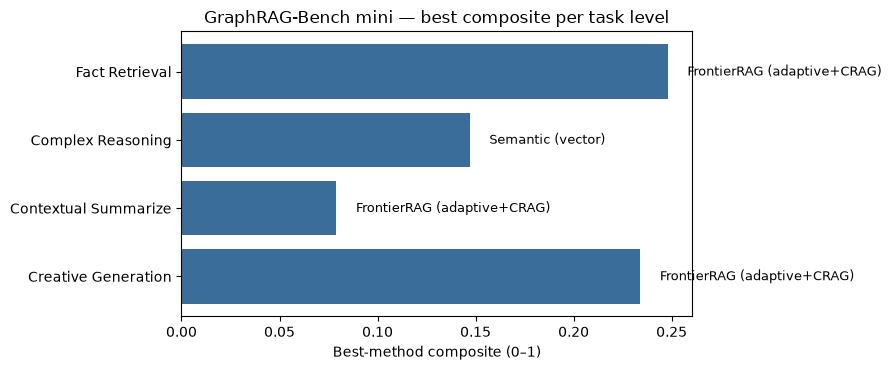

In [5]:
acc = pd.read_csv(RESULTS / "accuracy_results.csv")
if "graphrag_bench_type" not in acc.columns:
    qa_by_id = {q["id"]: q for q in json.loads(Path(built["qa_path"]).read_text())}
    acc["graphrag_bench_type"] = acc["question_id"].map(
        lambda i: qa_by_id.get(i, {}).get("graphrag_bench_type", "")
    )

# Drop rows whose question_id is not in the current subset (stale runs)
valid_ids = {q["id"] for q in qa}
stale = ~acc.question_id.isin(valid_ids)
if stale.any():
    display(Markdown(
        f"**Note:** {int(stale.sum())} result rows are from an older subset — "
        f"re-run with `RUN_BENCHMARK=True` for a clean leaderboard."
    ))

by_type = (
    acc.groupby(["graphrag_bench_type", "method"])[[
        "composite_score", "llm_judge_score", "token_f1", "exact_match", "contains_answer"
    ]]
    .mean()
    .reset_index()
)
by_type["label"] = by_type["method"].map(lambda m: METHOD_LABELS.get(m, m))

order = [
    "Fact Retrieval",
    "Complex Reasoning",
    "Contextual Summarize",
    "Creative Generation",
]
winners = []
for qt in order:
    sub = by_type[by_type.graphrag_bench_type == qt]
    if sub.empty:
        continue
    best = sub.loc[sub.composite_score.idxmax()]
    winners.append({
        "task_level": qt,
        "winner": best["label"],
        "composite": round(float(best.composite_score), 3),
        "judge": round(float(best.llm_judge_score), 3),
        "contains": round(float(best.contains_answer), 3),
        "em": round(float(best.exact_match), 3),
        "paper_hint": "vector OK" if qt == "Fact Retrieval" else "graphs help",
    })

display(Markdown("### Winners by task level"))
display(pd.DataFrame(winners))

pivot = by_type.pivot_table(
    index="label", columns="graphrag_bench_type", values="composite_score"
)
pivot = pivot.reindex(columns=[c for c in order if c in pivot.columns])
display(Markdown("### Composite by method × task level"))
display(pivot.round(3))

# Bar chart of winners' composites
if winners:
    fig, ax = plt.subplots(figsize=(9, 3.8))
    ax.barh(
        [w["task_level"] for w in winners][::-1],
        [w["composite"] for w in winners][::-1],
        color="#3b6d9a",
    )
    ax.set_xlabel("Best-method composite (0–1)")
    ax.set_title("GraphRAG-Bench mini — best composite per task level")
    for y, w in enumerate(winners[::-1]):
        ax.text(w["composite"] + 0.01, y, w["winner"], va="center", fontsize=9)
    plt.tight_layout()
    plt.show()


## 4. Metric autopsy (why EM looks “broken”)

GraphRAG-Bench gold answers are often **sentences**, not Hotpot-style spans. Exact match stays near zero; **LLM judge** and **contains** are the readable signals for demos.


### Mean metrics by method

,llm_judge_score,contains_answer,token_f1,exact_match
method,,,,
Vector + rerank,0.200,0.143,0.134,0.0
Hybrid (vec+graph local),0.243,0.000,0.111,0.0
Semantic (vector),0.294,0.143,0.148,0.0
FrontierRAG (adaptive+CRAG),0.314,0.143,0.150,0.0


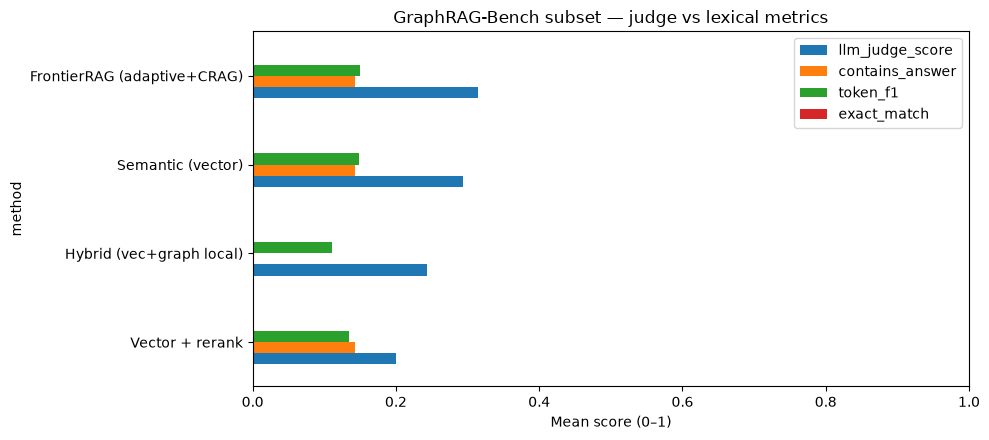

- **10/28** rows: judge ≥ 0.5 but EM = 0
- Prefer **judge + contains** for generative GraphRAG demos; EM/F1 for extractive spans only.

In [6]:
metric_means = (
    acc.groupby("method")[["llm_judge_score", "contains_answer", "token_f1", "exact_match"]]
    .mean()
    .rename(index=lambda m: METHOD_LABELS.get(m, m))
    .sort_values("llm_judge_score")
)
display(Markdown("### Mean metrics by method"))
display(metric_means.round(3))

fig, ax = plt.subplots(figsize=(10, 4.5))
metric_means.plot(kind="barh", ax=ax)
ax.set_xlim(0, 1)
ax.set_xlabel("Mean score (0–1)")
ax.set_title("GraphRAG-Bench subset — judge vs lexical metrics")
plt.tight_layout()
plt.show()

n = len(acc)
hi = int(((acc.llm_judge_score >= 0.5) & (~acc.exact_match.astype(bool))).sum())
display(Markdown(
    f"- **{hi}/{n}** rows: judge ≥ 0.5 but EM = 0\n"
    f"- Prefer **judge + contains** for generative GraphRAG demos; EM/F1 for extractive spans only."
))


## 5. Engineering scorecard + charts

Tokens, latency, and routing — what you ship, not just a single average.



=== BENCHMARK LEADERBOARD ===
                      label  mean_composite_score  mean_llm_judge  mean_token_f1  total_tokens  tokens_per_query  index_seconds  mean_query_latency_seconds  total_elapsed_seconds
          Semantic (vector)                 0.146           0.294          0.148         30588          4369.714          0.125                       5.595                 48.539
   Hybrid (vec+graph local)                 0.088           0.243          0.111         35512          5073.143          0.029                      16.466                124.727
            Vector + rerank                 0.119           0.200          0.134         31717          4531.000          0.028                       5.185                 44.122
FrontierRAG (adaptive+CRAG)                 0.152           0.314          0.150         48312          6901.714          0.071                       8.471                 68.689

=== QUALITY BY SCENARIO ===
query_type                   hybrid  local
la

# Engineering scorecard

Default interactive path: **Vector + rerank**
- Reason: No method met latency SLO; picking fastest mean latency
- Quality: 0.119 | usable: 29%
- p95 latency: 6.78s | tokens/query: 4531

## Routing (by scenario)
- **multi_hop** → Semantic (vector) (q=0.107, 4370 tok/q) — Bridge / cross-doc multi-hop → Semantic (vector) (quality tie → cheaper tokens). meanΔ=0.007 but H2H 2W-3L → prefer head-to-head winner
- **local_factoid** → Vector + rerank (q=0.248, 4531 tok/q) — Single-entity / comparison factoids → Vector + rerank (quality tie → cheaper tokens). quality tie → cheaper tokens

## Recommendations
- Ship a query router, not one RAG stack: local factoids vs multi-hop need different paths.
- MULTI_HOP: Semantic (vector) (q=0.11, Δ=0.01, 4370 tok/q) [cost tie-break].
- LOCAL_FACTOID: Vector + rerank (q=0.25, Δ=0.00, 4531 tok/q) [cost tie-break].
- Usable-answer leader (Hybrid (vec+graph local), 43%) differs from composite leader (FrontierRAG (adaptive+CRAG)) — pick the metric that matches your UX.
- Highest token cost: FrontierRAG (adaptive+CRAG) (6902 tok/q) — gate behind hard-query classifier.
- Misses p95≤5.0s SLO: Semantic (vector), Vector + rerank, Hybrid (vec+graph local), FrontierRAG (adaptive+CRAG). Keep interactive path on vector; run graph/hybrid async or on stronger GPUs.
- Rebuild GraphRAG indexes only on corpus change; amortize index_seconds over expected volume.

## Caveats
- Eval set size n=7 — treat rankings as directional, not production SLAs.
- Overlapping quality CIs are common at this n; trust large gaps (latency/tokens/local EM) over 0.01 composite deltas.
- Composite mixes EM/F1/judge; generative graph answers often lose on EM even when useful.
- Absolute latency depends on hardware + model size; use relative ordering for stack choice.


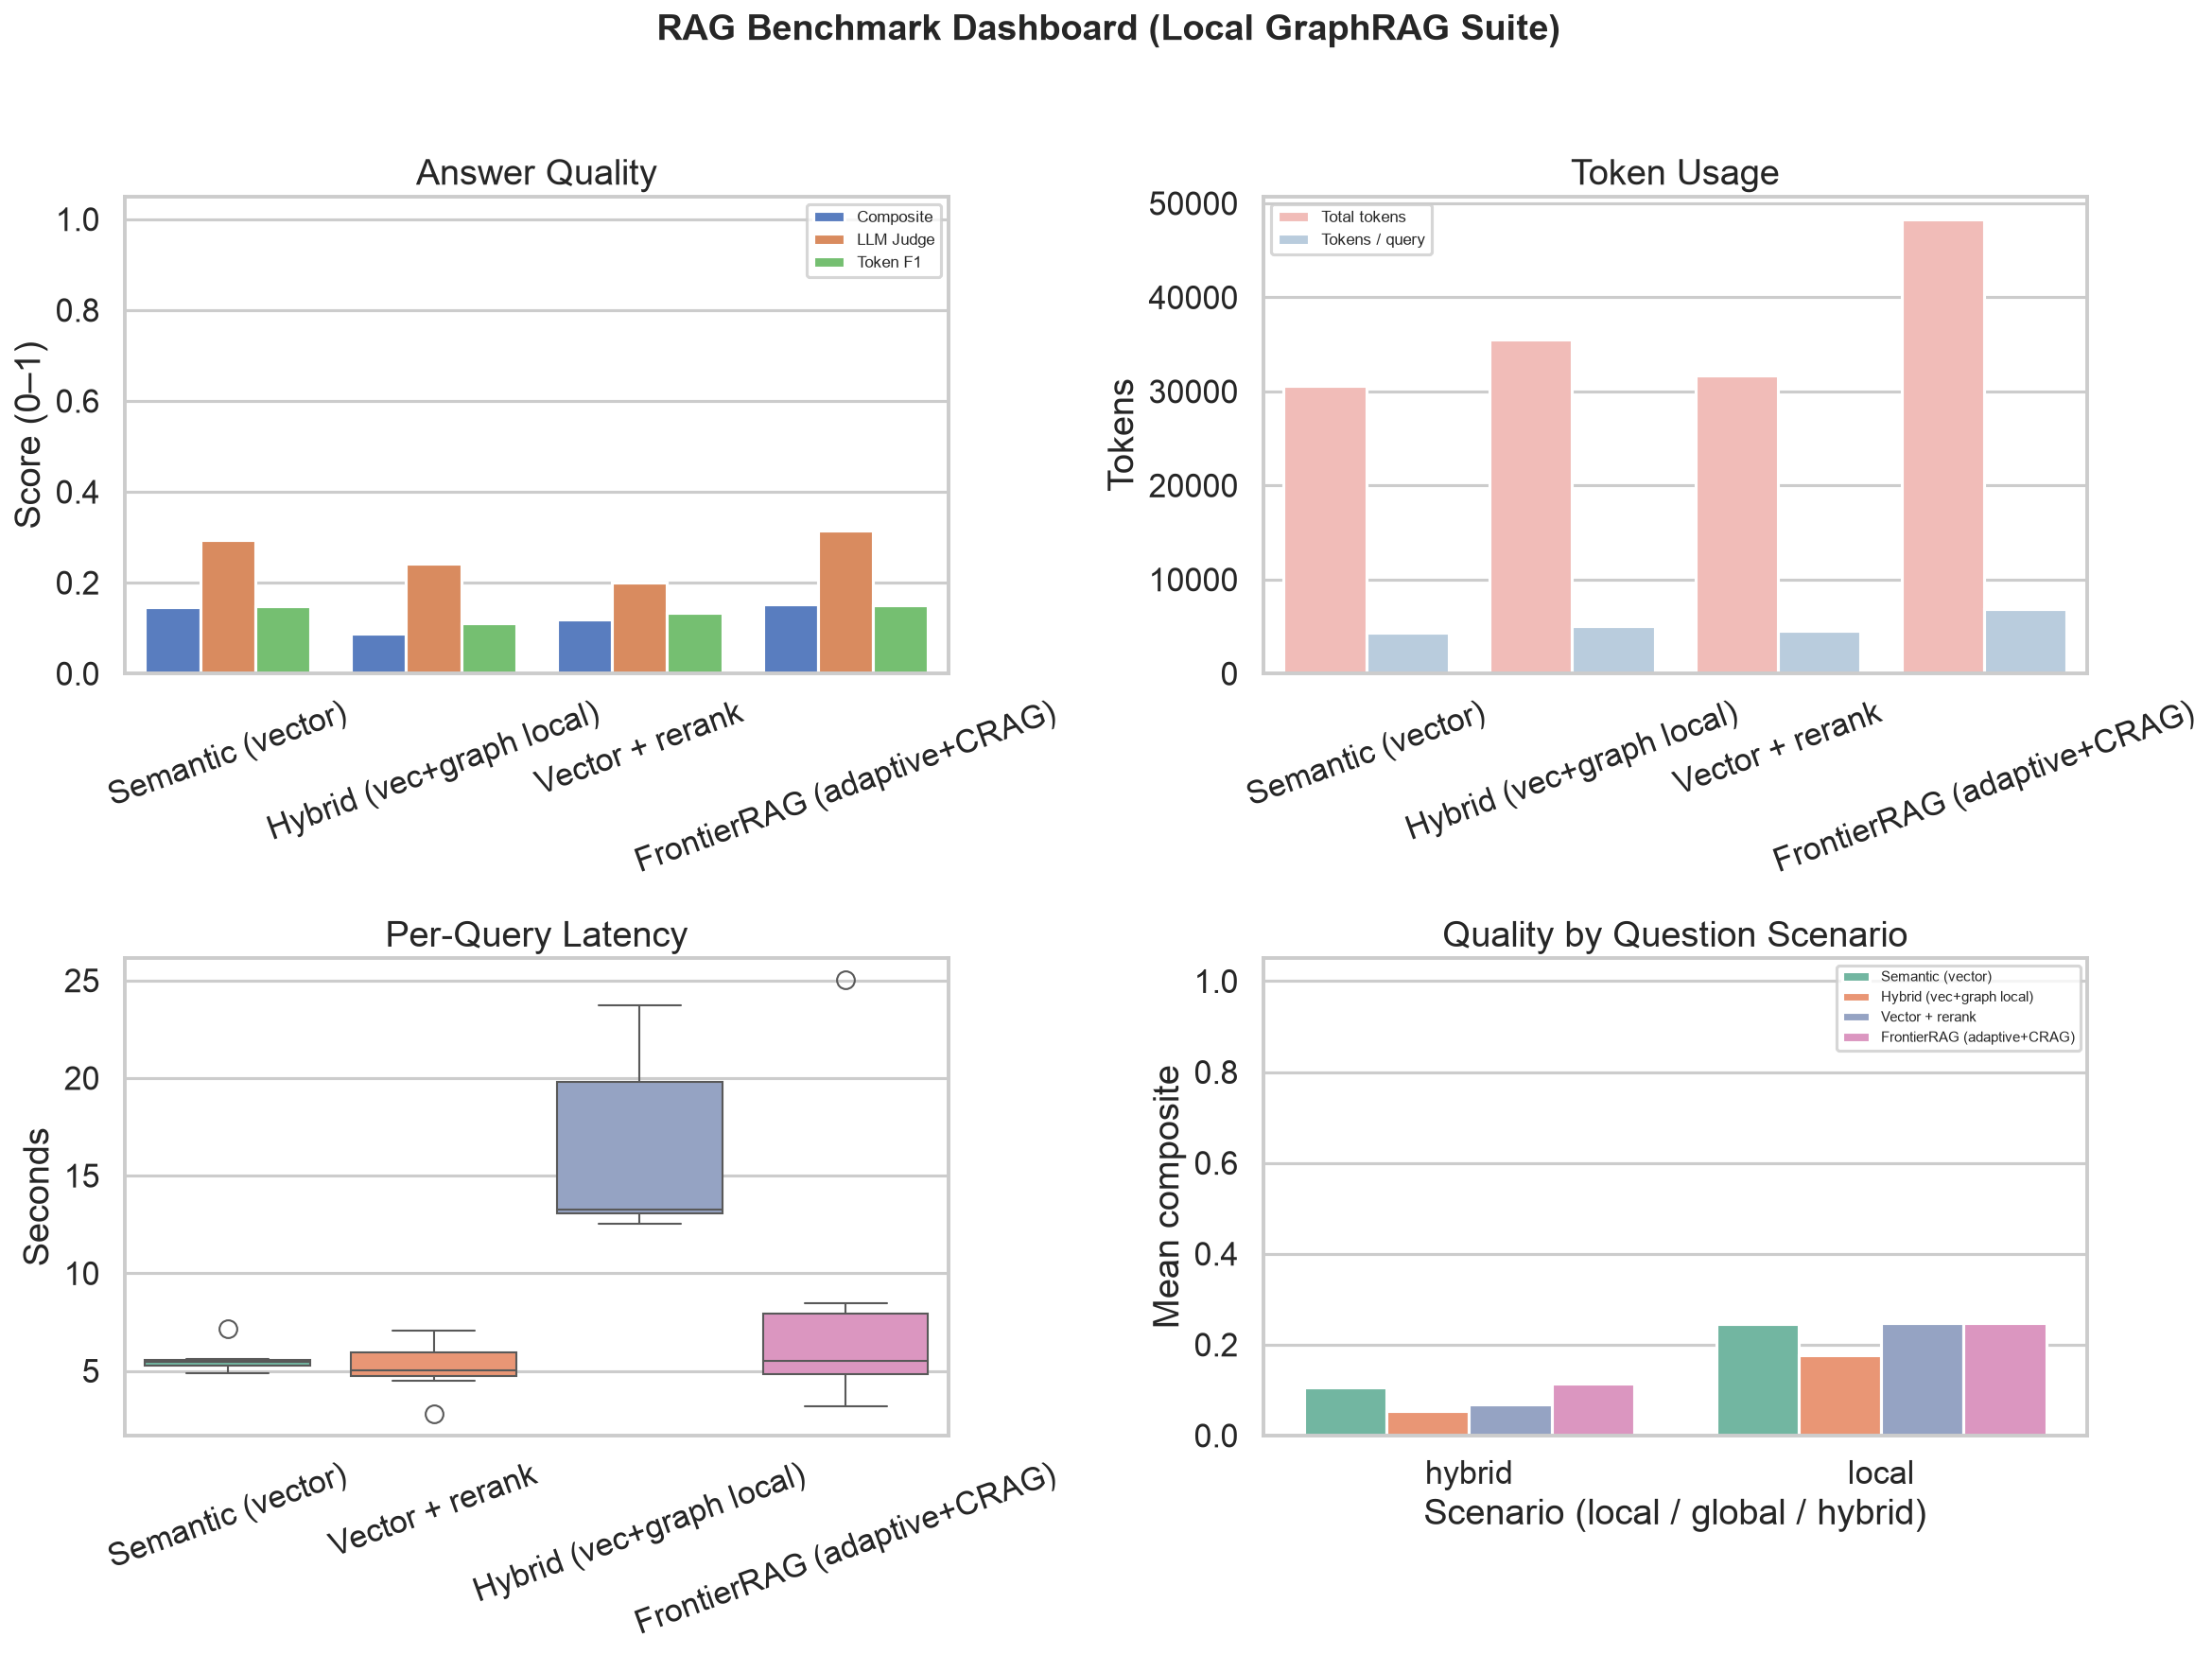

### Routing cheatsheet (truncated)

# When to choose which RAG (from *your* Hotpot data)

Cutting-edge production pattern (Adaptive-RAG): **route by query type**, don't crown a single stack.

- **multi-hop / bridge** (`hybrid`) → **Semantic (vector)** (mean 0.11)
- **comparison / local factoid** (`local`) → **FrontierRAG (adaptive+CRAG)** (mean 0.25)

## Pairwise takeaways
- Semantic vs Hybrid: Hybrid (vec+graph local) 1W–6W Semantic (vector) (mean Δ=-0.06)

## Research honesty: is this cutting edge?
- **Yes as an engineering bake-off**: FrontierRAG (Adaptive+CRAG escalate) + BM25/dense RRF + cross-encoder rerank + GraphRAG modes + HippoRAG 2/LightRAG is a 2025–2026-relevant *system* stack.
- **No as a SOTA paper claim**: n=12 Hotpot subset, local 3B judge=generator, no full BenchmarkQED AutoQ/AutoE LLM pairwise, LazyGraphRAG itself still not OSS.
- **Cutting-edge move**: ship the *router* that grades retrieval and escalates compute; keep the cost/latency scorecard; use stronger models for OpenIE and judging.

In [7]:
print_leaderboard(RESULTS)
brief = RESULTS / "engineering_briefing.md"
if brief.exists():
    display(Markdown(brief.read_text(encoding="utf-8")))
dash = RESULTS / "benchmark_dashboard.png"
if dash.exists():
    display(Image(filename=str(dash)))
cheat = RESULTS / "routing_cheatsheet.md"
if cheat.exists():
    display(Markdown("### Routing cheatsheet (truncated)"))
    display(Markdown(cheat.read_text(encoding="utf-8")[:3000]))


## 6. Full GraphRAG-Bench vs this harness

| Paper component | This demo |
|-----------------|-----------|
| Novel + Medical corpora | **Novel** mini-subset (one book, Pepys) |
| 4 task levels | Same labels; ~2 Qs each |
| Indexing / retrieval / generation evals | Generation (judge+EM+F1+contains) + tokens/latency |
| Official `Evaluation/` (ROUGE, coverage, faithfulness) | Next upgrade — wire their scripts for leaderboard parity |
| Public leaderboard | [graphrag-bench.github.io](https://graphrag-bench.github.io) |

**CLI**

```bash
PYTHONPATH=src python scripts/run_graphrag_bench.py semantic_rag,rerank_semantic,hybrid_rag,frontier_rag 2 Novel-4128
```

**Citation:** Xiang et al., *When to use Graphs in RAG*, ICLR 2026 — arXiv:2506.05690
